# Nu-Classifier Model — Inference Report

Evaluate the trained nu-classifier (DA) model on:
1. **MC NPY dataset** — sig-noise-filtered MC events from `nu_classifier_dataset_*`
2. **Exp NPY dataset** — sig-noise-filtered experimental events from the same directory

In [1]:
import datetime
import sys, os, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
%matplotlib inline
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

PROJECT_ROOT = Path(os.path.abspath("../.."))
sys.path.insert(0, str(PROJECT_ROOT))

# Reuse model loading + predict_scores from prefilter utils
from utils import load_model, predict_scores, load_npy_exp, load_raw_hits_for_npy_exp

%load_ext autoreload
%autoreload 2

## Configuration

In [24]:
MODEL_NAME      = "260509_1034_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed27_lr1e4_withprobs"
WITH_PROBS = True
CHECKPOINT_PATH = f"experiments/numu/{MODEL_NAME}/best_da_model.pth"
CHKPT_TAG = ""
# CHECKPOINT_PATH = f"experiments/numu/{MODEL_NAME}/da_checkpoint_epoch_025.pth"
# CHKPT_TAG = "_epoch025"

#NPY_DIR         = Path("data_manager/datasets/nu_classifier_TEST_dataset_h5s0_thr0.5")
NPY_DIR         = Path("data_manager/datasets/nu_classifier_dataset_h5s0_thr0.8")
NPY_DIR_EXP         = Path("data_manager/datasets/nu_classifier_dataset_h5s0_thr0.8")

DEVICE     = "cuda:2"
BATCH_SIZE = 1024
MAX_HITS   = 500
SEED       = 42

# Max events per particle type for MC inference (None = all)
MAX_MC_EVENTS_PER_TYPE = 5_000_000
# Max exp events for inference (None = all)
MAX_EXP_EVENTS = None

PARTICLE_COLORS = {
    "muatm_2020": "steelblue",
    "nuatm_2020": "tomato",
    "nue2_2020":  "seagreen",
}
PARTICLE_ENCODE = {"muatm_2020": 0, "nuatm_2020": 1, "nue2_2020": 2}
PARTICLE_DECODE = {v: k for k, v in PARTICLE_ENCODE.items()}

TIMESTAMP_STR = datetime.datetime.now().strftime("%y%m%d_%H%M%S")
FIGURES_DIR = PROJECT_ROOT / f"experiments/numu/{MODEL_NAME}/figures_{TIMESTAMP_STR}"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str) -> None:
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")


print(f"Model:    {MODEL_NAME}")
print(f"NPY dir:  {NPY_DIR}")
print(f"Figures: {FIGURES_DIR}")

Model:    260509_1034_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed27_lr1e4_withprobs
NPY dir:  data_manager/datasets/nu_classifier_TEST_dataset_h5s0_thr0.5
Figures: /home/albert/Baikal2025/experiments/numu/260509_1034_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed27_lr1e4_withprobs/figures_260510_092717


## 1. Load model

In [22]:
model_pref, norm_config, train_config = load_model(
    str(PROJECT_ROOT / CHECKPOINT_PATH), device=DEVICE
)
print(f"Normalization: means={norm_config['means']}, stds={norm_config['stds']}")
print(f"Model amp_clip: {model_pref.amp_clip:.4f} (normalized) "
      f"= Q≈{model_pref.amp_clip * norm_config['stds'][0] + norm_config['means'][0]:.1f} PE")

2026-05-10 09:26:15,970 INFO Created AttentionFeatureExtractor: 6→128, 4 layers, 4 heads, pooling=cls
2026-05-10 09:26:15,971 INFO Created BinaryClassifier: 128→[32, 16]→1, dropout=0.0, batch_norm=False
2026-05-10 09:26:15,971 INFO Created StandardNeutrinoModel with 404289 parameters
2026-05-10 09:26:15,973 INFO amp_clip: Q=100 PE → normalized=1.6333 (mean=2.0, std=60.0)
2026-05-10 09:26:15,976 INFO Loaded model from epoch 42 (best_metric=0.0027)


Normalization: means=[2.0, 0.0, 0.0, 0.0, 0.0], stds=[60.0, 1370.0, 40.0, 40.0, 150.0]
Model amp_clip: 1.6333 (normalized) = Q≈100.0 PE


## 2. Load MC NPY data

In [35]:
def load_npy_mc(npy_dir: Path, max_per_type: int = None, seed: int = 42, feats_with_probs: bool = False) -> pd.DataFrame:
    """Load MC events from nu_classifier NPY dataset into a DataFrame.

    Returns columns: particle_type (str), label (float), n_sig_hits (int),
    n_sig_strings (int), features (np.ndarray per event).
    """
    features_mmap   = np.load(npy_dir / "features.npy",      mmap_mode="r")
    offsets         = np.load(npy_dir / "offsets.npy")
    labels          = np.load(npy_dir / "labels.npy")
    n_sig_hits      = np.load(npy_dir / "n_sig_hits.npy")
    n_sig_strings   = np.load(npy_dir / "n_sig_strings.npy")
    n_gt_sig_hits   = np.load(npy_dir / "n_gt_sig_hits.npy")
    n_gt_sig_strings   = np.load(npy_dir / "n_gt_sig_strings.npy")
    particle_types  = np.load(npy_dir / "particle_types.npy")
    probs = np.load(npy_dir / "probs.npy",      mmap_mode="r")

    DECODE = {0: "muatm_2020", 1: "nuatm_2020", 2: "nue2_2020"}
    rng = np.random.RandomState(seed)

    selected: list[int] = []
    for code in sorted(DECODE):
        idx = np.where(particle_types == code)[0]
        if max_per_type is not None and len(idx) > max_per_type:
            idx = rng.choice(idx, size=max_per_type, replace=False)
        selected.append(idx)
    selected_idx = np.concatenate(selected)

    if feats_with_probs:
        rows = {
            "particle_type": [DECODE[int(particle_types[i])] for i in selected_idx],
            "label":         labels[selected_idx].tolist(),
            "n_sig_hits":    n_sig_hits[selected_idx].tolist(),
            "n_sig_strings": n_sig_strings[selected_idx].tolist(),
            "n_gt_sig_hits": n_gt_sig_hits[selected_idx].tolist(),
            "n_gt_sig_strings": n_gt_sig_strings[selected_idx].tolist(),
            "features":      [np.concat([
                np.array(features_mmap[offsets[i]:offsets[i+1]]),
                np.array(probs[offsets[i]:offsets[i+1], None]),
            ], axis=1) for i in selected_idx],
            "probs": [np.array(probs[offsets[i]:offsets[i+1]]) for i in selected_idx],
        }
    else:
        rows = {
            "particle_type": [DECODE[int(particle_types[i])] for i in selected_idx],
            "label":         labels[selected_idx].tolist(),
            "n_sig_hits":    n_sig_hits[selected_idx].tolist(),
            "n_sig_strings": n_sig_strings[selected_idx].tolist(),
            "n_gt_sig_hits": n_gt_sig_hits[selected_idx].tolist(),
            "n_gt_sig_strings": n_gt_sig_strings[selected_idx].tolist(),
            "features":      [np.array(features_mmap[offsets[i]:offsets[i+1]]) for i in selected_idx],
            "probs": [np.array(probs[offsets[i]:offsets[i+1]]) for i in selected_idx],
        }
    return pd.DataFrame(rows)


df_mc = load_npy_mc(PROJECT_ROOT / NPY_DIR, max_per_type=MAX_MC_EVENTS_PER_TYPE, seed=SEED, feats_with_probs=WITH_PROBS)
print(f"MC: {len(df_mc):,} events")
print(df_mc["particle_type"].value_counts())

MC: 3,893,512 events
particle_type
muatm_2020    1946756
nuatm_2020     973378
nue2_2020      973378
Name: count, dtype: int64


## 3. Load exp NPY data

In [36]:
import h5py
from tqdm.auto import tqdm
def load_clusters_geometry(exph5path="../../data_manager/data/h5datasets/exp.h5"):
    result = {}
    with h5py.File(exph5path) as hf:
        group = hf['exp']
        for part in tqdm(group['raw/data'], total=len(group['raw/data'].keys())):
            cluster = part.split('_')[2]
            if cluster not in result:
                result[cluster] = {}
            run = part.split('_')[3]
            xy = np.unique(group[f'raw/data/{part}/data'][:,[2,3]].round(0), axis=0)
            result[cluster][run] = xy
    return result

# geom_clusters = load_clusters_geometry() 
# for cluster, run_geom in geom_clusters.items():
#     fig = plt.figure(figsize=(3,3))
#     for run, xy in run_geom.items():
#         x, y = xy[:,0], xy[:,1]
#         plt.scatter(x, y)
#         plt.title(f"{cluster=}, {run=}")
#     plt.show()

In [ ]:
df_exp = load_npy_exp(PROJECT_ROOT / NPY_DIR_EXP, max_events=MAX_EXP_EVENTS, seed=SEED, feats_with_probs=WITH_PROBS)
df_exp['xy_coords'] = df_exp['features'].apply(lambda x: np.unique(x[:,[2,3]].round(0), axis=0))
df_exp['num_strings_est'] = df_exp['xy_coords'].apply(len)
print(f"Exp: {len(df_exp):,} events")

Exp: 39,130 events


In [ ]:
#load_raw_hits_for_npy_exp(df_exp, "/home/albert/Baikal2025/data_manager/data/h5datasets/exp.h5")

Text(0, 0.5, 'Density')

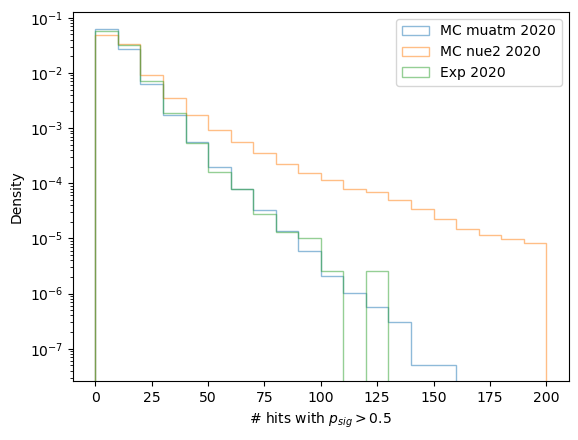

In [ ]:
muatm_hits = df_mc[df_mc['particle_type']=='muatm_2020']['n_sig_hits']
nue2_hits = df_mc[df_mc['particle_type']=='nue2_2020']['n_sig_hits']
exp_hits = df_exp['n_sig_hits']
plt.hist(muatm_hits, density=True, log=True, bins=20, range=(0,200), alpha=0.5, label='MC muatm 2020', histtype='step')
plt.hist(nue2_hits, density=True, log=True, bins=20, range=(0,200), alpha=0.5, label='MC nue2 2020', histtype='step')
plt.hist(exp_hits, density=True, log=True, bins=20, range=(0,200), alpha=0.5, label='Exp 2020', histtype='step')
plt.xlabel(r'# hits with $p_{sig}>0.5$')
plt.legend()
plt.ylabel('Density')

In [29]:
(exp_hits>125).sum()/len(exp_hits)

np.float64(0.0)

## 4. Predict scores

In [ ]:
# # Additional Filtering
# filter_mask = df_mc['probs'].apply(lambda x: (x>0.8).sum()>=8)
# df_mc = df_mc[filter_mask]

In [39]:
df_mc["score"] = predict_scores(
    model_pref, df_mc["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
    feats_with_probs=WITH_PROBS
)
print(f"MC scores:  mean={df_mc['score'].mean():.4f}, median={df_mc['score'].median():.4f}")

Predicting:   0%|          | 0/1189 [00:00<?, ?batch/s]

MC scores:  mean=0.4967, median=0.1240


In [40]:
df_exp["score"] = predict_scores(
    model_pref, df_exp["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
    feats_with_probs=WITH_PROBS
)
print(f"Exp scores: mean={df_exp['score'].mean():.4f}, median={df_exp['score'].median():.4f}")

Predicting:   0%|          | 0/39 [00:00<?, ?batch/s]

Exp scores: mean=0.0321, median=0.0143


## 5. Score distributions

Saved: /home/albert/Baikal2025/experiments/numu/260509_1034_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed27_lr1e4_withprobs/figures_260510_092717/score_dist_per_particle.png


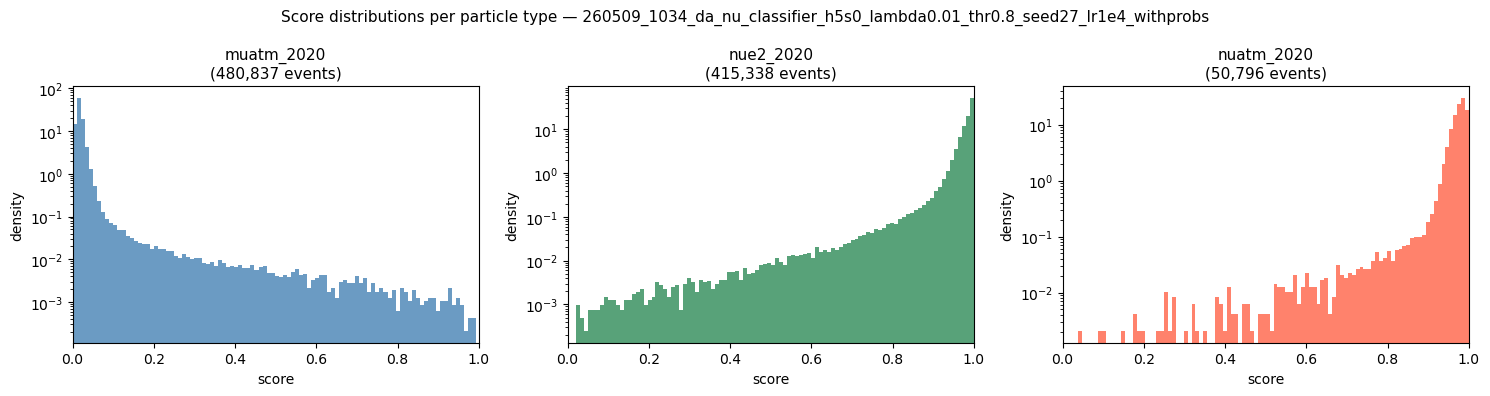

In [41]:
# ── Per particle type (MC) ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


mask_mc = (df_mc['n_sig_hits']>=8) & (df_mc['n_sig_strings']>=3)
for ax, ptype in zip(axes, ["muatm_2020", "nue2_2020", "nuatm_2020"]):
    sub = df_mc[(df_mc["particle_type"] == ptype) & mask_mc]
    color = PARTICLE_COLORS[ptype]
    ax.hist(sub["score"], bins=100, alpha=0.8, log=True, density=True, color=color)
    ax.set_title(f"{ptype}\n({len(sub):,} events)", fontsize=11)
    ax.set_xlabel("score")
    ax.set_ylabel("density")
    ax.set_xlim(0, 1)

fig.suptitle(f"Score distributions per particle type — {MODEL_NAME}", fontsize=11)
plt.tight_layout()
save_figure(fig, f"score_dist_per_particle{CHKPT_TAG}.png")
plt.show()

Saved: /home/albert/Baikal2025/experiments/numu/260509_1034_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed27_lr1e4_withprobs/figures_260510_092717/score_dist_mc_exp.png


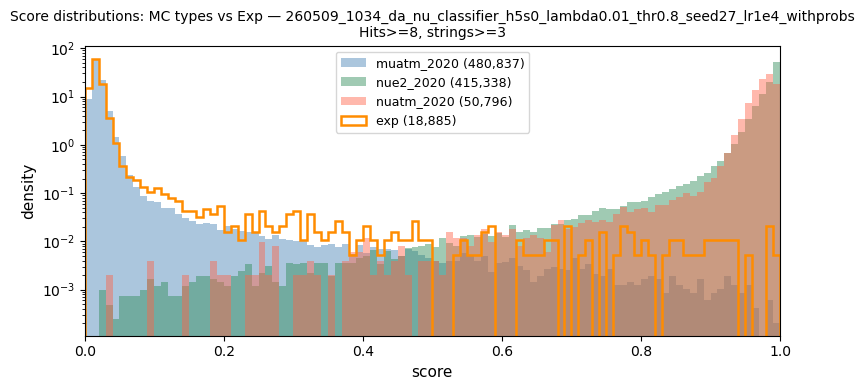

In [42]:
# ── MC types + Exp overlay (density, log) ──
fig, ax = plt.subplots(figsize=(8, 4))

H_CUT, S_CUT = 8, 3
mask_mc = (df_mc['n_sig_hits']>=H_CUT) & (df_mc['n_sig_strings']>=S_CUT)
mask_exp = (df_exp['n_sig_hits']>=H_CUT) & (df_exp['num_strings_est']>=S_CUT)
for ptype in ["muatm_2020", "nue2_2020", "nuatm_2020"]:
    sub = df_mc[(df_mc["particle_type"] == ptype) & mask_mc]
    ax.hist(sub["score"], bins=100, alpha=0.45, log=True, density=True,
            color=PARTICLE_COLORS[ptype], label=f"{ptype} ({len(sub):,})", range=(0,1))

ax.hist(df_exp[mask_exp]["score"], bins=100, log=True, density=True, histtype="step",
        color="darkorange", linewidth=1.8, label=f"exp ({len(df_exp[mask_exp]):,})", range=(0,1))

ax.set_xlabel("score", fontsize=11)
ax.set_ylabel("density", fontsize=11)
ax.set_xlim(0, 1)
ax.legend(fontsize=9)
ax.set_title(f"Score distributions: MC types vs Exp — {MODEL_NAME}\nHits>={H_CUT}, strings>={S_CUT}", fontsize=10)
plt.tight_layout()
save_figure(fig, f"score_dist_mc_exp{CHKPT_TAG}.png")
plt.show()

## Strange events analysis

In [43]:
df_strange = df_exp[(df_exp["score"]>0.95) & mask_exp]

print(len(df_strange))

6


In [44]:
from inference.prefilter_model.utils import load_model as pref_load_model, predict_scores as pref_pred_scores, plot_event_3d

PREF_MODEL_NAME = "da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss"
#CHECKPOINT_PATH = "experiments/numu/da_prefilter_numu_260327_0127/best_da_model.pth"
#CHECKPOINT_PATH = "experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/best_da_model.pth"
PREF_CHECKPOINT_PATH = f"experiments/numu/{PREF_MODEL_NAME}/best_da_model.pth"

model_pref, norm_config, train_config = pref_load_model(
    str(PROJECT_ROOT / PREF_CHECKPOINT_PATH), device=DEVICE
)
print(f"Normalization: means={norm_config['means']}, stds={norm_config['stds']}")
print(f"Model amp_clip: {model_pref.amp_clip:.4f} (normalized) "
      f"= Q≈{model_pref.amp_clip * norm_config['stds'][0] + norm_config['means'][0]:.1f} PE")

# Match strange exp events from exp.h5 and load raw events inclusing noises!
df_strange_withraw = load_raw_hits_for_npy_exp(df_strange, "/home/albert/Baikal2025/data_manager/data/h5datasets/exp.h5")
df_strange_withraw['times'] = df_strange_withraw['features'].apply(lambda x: x[:,1])
df_strange_withraw['mask'] = df_strange_withraw.apply(
    lambda row: np.isin(row['raw_times'], row['times']), axis=1
)

# Predict scores by prefilter model
pref_features = df_strange_withraw['features'].apply(lambda x: x[:,:5]).tolist() if WITH_PROBS else df_strange_withraw['features'].tolist()
df_strange_withraw['pref_score'] = pref_pred_scores(model_pref, pref_features, norm_config, batch_size=BATCH_SIZE, device=DEVICE)
display(df_strange_withraw)

2026-05-10 09:33:11,130 INFO Created AttentionFeatureExtractor: 5→128, 4 layers, 4 heads, pooling=cls
2026-05-10 09:33:11,131 INFO Created BinaryClassifier: 128→[32, 16]→1, dropout=0.0, batch_norm=False
2026-05-10 09:33:11,132 INFO Created StandardNeutrinoModel with 404161 parameters
2026-05-10 09:33:11,134 INFO amp_clip: Q=100 PE → normalized=1.6333 (mean=2.0, std=60.0)
2026-05-10 09:33:11,136 INFO Loaded model from epoch 39 (best_metric=0.9982)


Normalization: means=[2.0, 0.0, 0.0, 0.0, 0.0], stds=[60.0, 1370.0, 40.0, 40.0, 150.0]
Model amp_clip: 1.6333 (normalized) = Q≈100.0 PE


Predicting:   0%|          | 0/1 [00:00<?, ?batch/s]

,part_names,n_sig_hits,n_sig_strings,channels,features,probs,xy_coords,num_strings_est,score,raw_channels,raw_times,raw_charges,times,mask,pref_score
5823,part_s2020_c02_r0206_9828,8,2,"[41, 39, 40, 38, 41, 37, 42, 227]","[[1.6880621, -124.535324, 60.382084, 7.9202814...","[0.8809033, 0.94698083, 0.95697755, 0.9471594,...","[[-23.0, 55.0], [60.0, 8.0], [61.0, 8.0]]",3,0.990319,"[44, 89, 145, 116, 124, 73, 90, 84, 245, 116, ...","[-2634.9866, -2630.5266, -2343.9182, -2284.293...","[0.41387135, 0.8135638, 1.3039505, 0.4262089, ...","[-124.535324, -110.48845, -101.432785, -82.579...","[False, False, False, False, False, False, Fal...",0.994282
11773,part_s2020_c03_r0417_11979,18,4,"[82, 83, 84, 85, 46, 45, 47, 118, 44, 48, 262,...","[[161.66559, -217.33423, 57.48723, -20.436909,...","[0.92454463, 0.9320487, 0.94611037, 0.8896623,...","[[-3.0, -0.0], [18.0, -56.0], [50.0, 32.0], [5...",5,0.983104,"[147, 282, 67, 281, 172, 132, 137, 276, 150, 8...","[-2662.3596, -2554.306, -2503.8928, -2438.464,...","[0.47989962, 1.2495708, 0.4605695, 0.92904717,...","[-217.33423, -167.87427, -99.677, -27.33325, -...","[False, False, False, False, False, False, Fal...",0.994259
18074,part_s2020_c04_r0116_23484,18,4,"[154, 155, 191, 153, 190, 189, 156, 192, 157, ...","[[37.022274, -265.65485, -31.339838, -49.67178...","[0.93147826, 0.94966817, 0.9541679, 0.9433832,...","[[-59.0, -7.0], [-31.0, -50.0], [-31.0, -49.0]...",5,0.986167,"[89, 260, 243, 96, 224, 103, 203, 138, 15, 69,...","[-2614.9097, -2535.3472, -2491.7827, -2456.057...","[1.4333798, 0.99500126, 1.2230932, 1.0395964, ...","[-265.65485, -229.85406, -219.22906, -212.4243...","[False, False, False, False, False, False, Fal...",0.993820
18232,part_s2020_c04_r0117_731,9,3,"[185, 186, 184, 187, 184, 253, 254, 72, 198]","[[6.0253143, -271.91968, -58.96885, -6.7804093...","[0.9392545, 0.8152719, 0.85521746, 0.8837949, ...","[[-59.0, -7.0], [-2.0, 1.0], [54.0, -20.0]]",3,0.989452,"[181, 195, 31, 105, 198, 71, 71, 270, 57, 198,...","[-2373.2507, -2223.3406, -2057.7927, -2048.626...","[0.76509225, 0.7443616, 1.3182924, 1.3337855, ...","[-271.91968, -267.96558, -261.7146, -255.34938...","[False, False, False, False, False, False, Fal...",0.934834
18410,part_s2020_c04_r0117_13476,14,5,"[198, 178, 179, 177, 283, 282, 285, 213, 248, ...","[[464.47162, -1273.4656, -58.946976, -6.846846...","[0.86984944, 0.89288914, 0.8665076, 0.88688904...","[[-59.0, -7.0], [-39.0, 39.0], [-30.0, -48.0],...",5,0.956714,"[237, 246, 159, 71, 135, 71, 71, 20, 34, 101, ...","[-2446.5544, -2415.2927, -2367.068, -2360.3699...","[1.2424891, 1.1359242, 1.1012295, 2.3508606, 1...","[-1273.4656, 8.896705, 17.759985, 29.71018, 14...","[False, False, False, False, False, False, Fal...",0.061161
18510,part_s2020_c04_r0117_20084,11,3,"[147, 183, 182, 181, 183, 184, 180, 217, 216, ...","[[68.36301, -193.49963, -31.159481, -50.034805...","[0.92494076, 0.9286269, 0.94995886, 0.9027045,...","[[-59.0, -7.0], [-40.0, 40.0], [-40.0, 41.0], ...",4,0.981401,"[276, 159, 172, 172, 146, 71, 141, 137, 147, 2...","[-2398.0444, -2341.3706, -2284.1792, -2107.075...","[1.232778, 1.8666353, 1.2637349, 1.5065731, 1....","[-193.49963, -54.35119, -25.377558, -3.7799015...","[False, False, False, False, False, False, Fal...",0.984989


In [20]:
import json, re
from pathlib import Path

def _parse_part_name(part_name: str):
    m = re.match(r'part_s(\d+)_c(\d+)_r(\d+)_\d+', part_name)
    return int(m.group(1)), int(m.group(2)), int(m.group(3))

OUT_DIR = Path(f"candidates/events_{MODEL_NAME}{CHKPT_TAG}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for event_id, row in df_strange_withraw.iterrows():
    season, cluster, run = _parse_part_name(row['part_names'])
    pulses = {
        str(i): {
            "mask":      int(row['mask'][i]),
            "amplitude": float(row['raw_charges'][i]),
            "charge":    float(row['raw_charges'][i]),
            "time":      float(row['raw_times'][i]),
            "channelID": int(row['raw_channels'][i]),
        }
        for i in range(len(row['raw_times']))
    }
    event = {
        "eventID": int(event_id),
        "season":  season,
        "cluster": cluster,
        "run":     run,
        "pulses":  pulses,
    }
    with open(OUT_DIR / f"event_{row['part_names']}.json", "w") as f:
        json.dump(event, f, indent=2)

print(f"Saved {len(df_strange_withraw)} events to {OUT_DIR}/")

Saved 6 events to candidates/events_260509_1034_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed27_lr1e4_withprobs/


In [24]:
def get_unique_strings_xy(run_xy):
    expansion_diff = np.abs((run_xy)[:,:,None] - (run_xy).T[None, :,:])
    expansion_diff = np.sqrt(expansion_diff[:,0,:]**2 + expansion_diff[:,1,:]**2)
    similar_ids = np.argwhere((expansion_diff>0) & (expansion_diff<6))
    keep_ids = []
    bad_ids = []
    for k, v in similar_ids:
        if k in bad_ids:
            continue
        if k not in keep_ids:
            keep_ids.append(k)
        bad_ids.append(v)
    #geom_clusters['c01']['r0027'][keep_ids]
    return run_xy[keep_ids]

if False:
    df_strange['geom'] = None
    for i, row in df_strange.iterrows():
        matches_dict = {}
        max_match = -1
        for cluster, run_geom in geom_clusters.items():
            matches_dict[cluster] = {}
            run_matches_dict = {}
            for run, xy in run_geom.items():
                run_matches_dict[run] = sum([(el in xy) for el in row['xy_coords']])
                #matches.append(sum([(el in xy) for el in row['xy_coords']]))
            runs_max_match = max(run_matches_dict.values())
            matches_dict[cluster] = run_matches_dict
        
        best_cluster = pd.DataFrame(matches_dict).max(axis=0).sort_values(ascending=False).index[0]
        best_run = pd.Series(matches_dict[best_cluster]).idxmax()
        df_strange.loc[i, 'cluster'] = best_cluster
        df_strange.loc[i, 'run'] = best_run
        df_strange.at[i, 'geom'] = get_unique_strings_xy(geom_clusters[best_cluster][best_run])


    import matplotlib.pyplot as plt
    from utils import plot_event_3d
    %matplotlib inline
    plt.close()

    for i in range(min(len(df_strange), 10)):
        event = df_strange.iloc[i]
        sig_mask = np.ones(event['features'].shape[0], dtype=bool) & (event['probs']>0.75)
        fig, ax = plot_event_3d(event['features'], sig_mask, title=f"Event 3D view\nCluster {event['cluster']}, Run {event['run']}\nScore={event['score']:.3f}")
        xstrings, ystrings = event['geom'][:,0], event['geom'][:,1]
        # Add vertival lines having x,y coordinates from xstrings, ystrings
        z = event['features'][:, 4]
        z_min, z_max = z.min(), z.max()
        z_pad = (z_max - z_min) * 0.15
        for xs, ys in zip(xstrings, ystrings):
            ax.plot([xs, xs], [ys, ys], [z_min - z_pad, z_max + z_pad],
                    color='gray', alpha=0.8, linewidth=2.0, linestyle='--')
        plt.tight_layout()
        plt.show()
        save_figure(fig, f'StrangeExpEvent_{i}.png')
        plt.close()
    plt.close()

<Axes: >

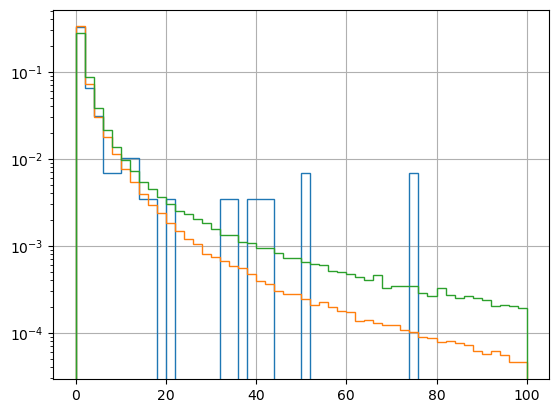

In [75]:
df_strange['features'].apply(lambda x: x[:,0]).explode().hist(bins=50, log=True, density=True, histtype='step', range=(0,100))
df_exp[mask_exp]['features'].apply(lambda x: x[:,0]).explode().hist(bins=50, log=True, density=True, histtype='step', range=(0,100))
df_mc[mask_mc]['features'].sample(10_000).apply(lambda x: x[:,0]).explode().hist(bins=50, log=True, density=True, histtype='step', range=(0,100))

## 6. Signal Efficiency & Background Suppression vs threshold (MC)

Signal = neutrino events (`label == 1`).  Background = muatm events (`label == 0`).

Quality cut options applied symmetrically to both signal and background:
- **No cuts** — all events (already filtered by sig-noise model)
- **hits >= 8** — `n_sig_hits >= 8`

Reference vertical line: **TPR = 99%** on the quality-cut curve.

In [45]:
from sklearn.metrics import roc_curve

SUPP_CLIP      = 1_000_000
REF_TPR_TARGET = 0.85
HIT_CUTS       = [0, 8]
CUT_LABELS     = ["No cuts", "n_sig_hits≥8"]
CUT_COLORS     = ["grey", None]

scores_arr    = df_mc["score"].values
sig_hits_arr  = np.array(df_mc["n_sig_hits"])
is_nu_arr     = df_mc["label"].values.astype(bool)
is_muon_arr   = ~is_nu_arr
ptypes_arr    = df_mc["particle_type"].values


def quality_mask(h: int) -> np.ndarray:
    if h == 0:
        return np.ones(len(df_mc), dtype=bool)
    return sig_hits_arr >= h


def balanced_subsample_nu(pos_mask: np.ndarray, seed: int = SEED) -> np.ndarray:
    """Subsample positives down to muon count."""
    n_neg = int(is_muon_arr.sum())
    pos_idx = np.where(pos_mask)[0]
    chosen = np.random.default_rng(seed).choice(pos_idx, size=min(n_neg, len(pos_idx)), replace=False)
    m = np.zeros(len(df_mc), dtype=bool)
    m[chosen] = True
    return m


def get_ref_point(pos_mask: np.ndarray, sub_mask: np.ndarray = None):
    """(threshold, suppression) at TPR ≈ REF_TPR_TARGET using quality_mask(8)."""
    base_pos = pos_mask if sub_mask is None else (pos_mask & sub_mask)
    q        = quality_mask(8)
    keep     = (base_pos & q) | (is_muon_arr & q)
    y_true   = base_pos[keep].astype(int)
    y_score  = scores_arr[keep]
    fpr, tpr, thr = roc_curve(y_true, y_score)
    thr = thr[1:][::-1]; tpr = tpr[1:][::-1]; fpr = fpr[1:][::-1]
    supp = np.where(fpr > 0, 1.0 / fpr, np.nan)
    idx  = np.searchsorted(-tpr, -REF_TPR_TARGET)
    idx  = min(idx, len(thr) - 1)
    return float(thr[idx]), float(supp[idx])


def plot_tpr_suppression(ax, pos_mask, title, sub_mask=None):
    ax_supp = ax.twinx()
    ax_supp.set_yscale("log")

    tpr_handles, supp_handles = [], []
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    auto_color_idx = 0

    for h, color, lbl in zip(HIT_CUTS, CUT_COLORS, CUT_LABELS):
        if color is None:
            color = prop_cycle[auto_color_idx % len(prop_cycle)]
            auto_color_idx += 1

        base_pos = pos_mask if sub_mask is None else (pos_mask & sub_mask)
        q   = quality_mask(h)
        keep = (base_pos & q) | (is_muon_arr & q)
        y_true  = base_pos[keep].astype(int)
        y_score = scores_arr[keep]
        n_sig, n_bg = y_true.sum(), (~y_true.astype(bool)).sum()
        if n_sig == 0 or n_bg == 0:
            continue

        fpr, tpr, thr = roc_curve(y_true, y_score)
        thr = thr[1:][::-1]; tpr = tpr[1:][::-1]; fpr = fpr[1:][::-1]
        supp = np.clip(np.where(fpr > 0, 1.0 / fpr, np.nan), None, SUPP_CLIP)
        clip = (thr >= 0) & (thr <= 1)

        ax.plot(thr[clip], tpr[clip], color=color, lw=2, ls="-")
        ax_supp.plot(thr[clip], supp[clip], color=color, lw=2, ls="--")
        tpr_handles.append(Line2D([0],[0], color=color, lw=2, ls="-",
                                  label=f"{lbl}  (#nu={n_sig:,})"))
        supp_handles.append(Line2D([0],[0], color=color, lw=2, ls="--",
                                   label=f"{lbl}  (#mu={n_bg:,})"))

    ref_thr, ref_supp = get_ref_point(pos_mask, sub_mask)
    ref_supp_c = min(ref_supp, SUPP_CLIP)
    ax.axvline(ref_thr, color="red", lw=1.4, ls=":")
    tpr_handles.append(Line2D([0],[0], color="red", lw=1.4, ls=":",
                               label=f"{int(REF_TPR_TARGET*100)}% ν eff @ thr={ref_thr:.3f}"))
    ax_supp.annotate(
        f"Supp={ref_supp:.0f}", xy=(ref_thr, ref_supp_c),
        xytext=(ref_thr - 0.22, ref_supp_c),
        fontsize=11, color="red", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="red", lw=1.2), va="center",
    )
    print(ref_supp)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax_supp.set_ylim(bottom=1)
    ax.set_xlabel("Classification threshold", fontsize=11)
    ax.set_ylabel(r"$\nu$ Efficiency (TPR)", fontsize=11)
    ax_supp.set_ylabel(r"EAS Suppression ($FPR^{-1}$)", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.grid(which="major", alpha=0.3)
    ax.grid(which="minor", alpha=0.12)
    ax.legend(handles=tpr_handles, fontsize=8.5, loc=(0.01, 0.72),
              framealpha=0.85, title="Efficiency (solid)", title_fontsize=8.5)
    ax_supp.legend(handles=supp_handles, fontsize=8.5, loc=(0.07, 0.1),
                   framealpha=0.85, title="Suppression (dashed)", title_fontsize=8.5)
    ax_supp.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )
    return ax_supp

Case 1 balanced: 605,044 positives / 611,693 negatives


/tmp/ipykernel_4157409/1654549759.py:71: RuntimeWarning: divide by zero encountered in divide
  supp = np.clip(np.where(fpr > 0, 1.0 / fpr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_4157409/1654549759.py:71: RuntimeWarning: divide by zero encountered in divide
  supp = np.clip(np.where(fpr > 0, 1.0 / fpr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_4157409/1654549759.py:41: RuntimeWarning: divide by zero encountered in divide
  supp = np.where(fpr > 0, 1.0 / fpr, np.nan)
/tmp/ipykernel_4157409/1654549759.py:71: RuntimeWarning: divide by zero encountered in divide
  supp = np.clip(np.where(fpr > 0, 1.0 / fpr, np.nan), None, SUPP_CLIP)


152923.25


/tmp/ipykernel_4157409/1654549759.py:71: RuntimeWarning: divide by zero encountered in divide
  supp = np.clip(np.where(fpr > 0, 1.0 / fpr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_4157409/1654549759.py:41: RuntimeWarning: divide by zero encountered in divide
  supp = np.where(fpr > 0, 1.0 / fpr, np.nan)


152923.25


/tmp/ipykernel_4157409/1654549759.py:71: RuntimeWarning: divide by zero encountered in divide
  supp = np.clip(np.where(fpr > 0, 1.0 / fpr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_4157409/1654549759.py:71: RuntimeWarning: divide by zero encountered in divide
  supp = np.clip(np.where(fpr > 0, 1.0 / fpr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_4157409/1654549759.py:41: RuntimeWarning: divide by zero encountered in divide
  supp = np.where(fpr > 0, 1.0 / fpr, np.nan)


152923.25
Saved: /home/albert/Baikal2025/experiments/numu/260509_1034_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed27_lr1e4_withprobs/figures_260510_092717/tpr_suppression.png


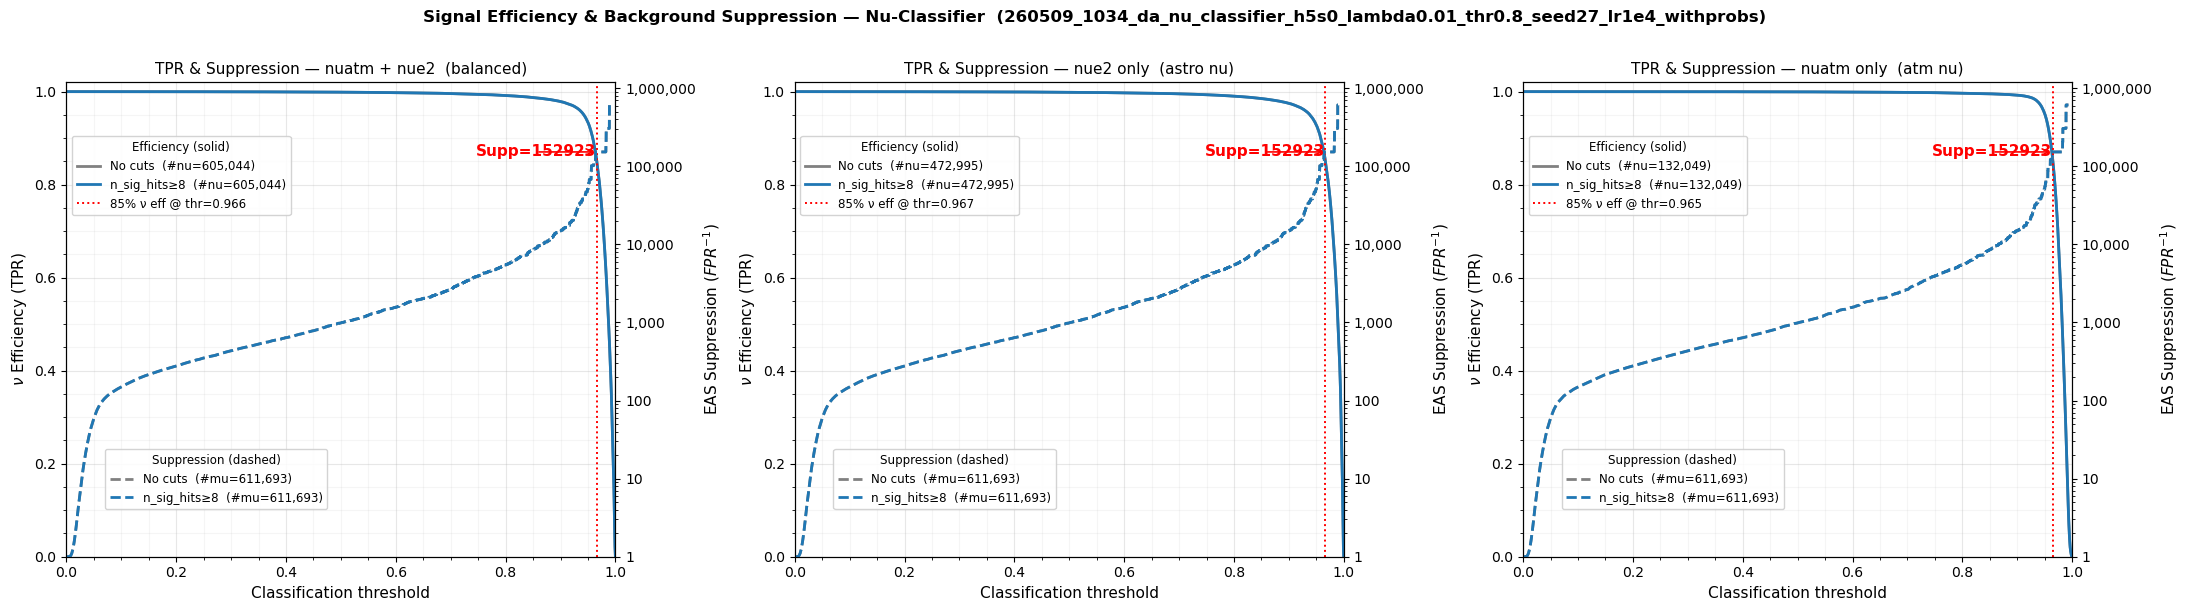

In [46]:
pos_both  = is_nu_arr.copy()
sub_both  = balanced_subsample_nu(pos_both)
pos_nue2  = (ptypes_arr == "nue2_2020")
pos_nuatm = (ptypes_arr == "nuatm_2020")

n_pos_bal = (pos_both & sub_both).sum()
n_neg     = is_muon_arr.sum()
print(f"Case 1 balanced: {n_pos_bal:,} positives / {n_neg:,} negatives")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

cases = [
    (pos_both,  sub_both, "nuatm + nue2  (balanced)"),
    (pos_nue2,  None,     "nue2 only  (astro nu)"),
    (pos_nuatm, None,     "nuatm only  (atm nu)"),
]

for ax, (pos_mask, sub_mask, label) in zip(axes, cases):
    plot_tpr_suppression(ax, pos_mask, title=f"TPR & Suppression — {label}", sub_mask=sub_mask)

fig.suptitle(
    f"Signal Efficiency & Background Suppression — Nu-Classifier  ({MODEL_NAME})",
    fontsize=12, fontweight="bold", y=1.01,
)
fig.tight_layout()
save_figure(fig, "tpr_suppression.png")
plt.show()

In [60]:
df_strange

,part_names,n_sig_hits,n_sig_strings,channels,features,probs,xy_coords,num_strings_est,score
5196,part_s2020_c01_r0188,10,4,"[114, 115, 116, 117, 116, 79, 77, 80, 43, 261]","[[17.933388, 155.581, 18.904774, -55.767757, -...","[0.9329716, 0.9260461, 0.8972357, 0.9142452, 0...","[[4.0, -0.0], [19.0, -56.0], [49.0, 34.0], [62...",5,0.965924
6911,part_s2020_c02_r0015,18,6,"[8, 8, 8, 8, 11, 8, 178, 285, 143, 141, 142, 1...","[[6.0165696, -1041.1195, 29.24558, 50.870953, ...","[0.5521922, 0.7075562, 0.68686676, 0.68228513,...","[[-51.0, -31.0], [-3.0, -57.0], [-3.0, -56.0],...",7,0.990564
12910,part_s2020_c03_r0012,9,4,"[153, 262, 263, 51, 88, 58, 58, 60, 58]","[[1.437977, -307.95425, -31.17188, -49.571163,...","[0.5643921, 0.883743, 0.8899762, 0.73136365, 0...","[[-31.0, -50.0], [-3.0, -0.0], [50.0, 32.0], [...",4,0.981911
20407,part_s2020_c03_r0417,27,6,"[82, 83, 81, 84, 85, 46, 79, 45, 47, 118, 44, ...","[[161.66559, -217.33423, 57.48723, -20.436909,...","[0.92454463, 0.9320487, 0.7990115, 0.94611037,...","[[-58.0, -4.0], [-40.0, 42.0], [-3.0, 0.0], [1...",8,0.990553
30130,part_s2020_c04_r0116,8,3,"[255, 75, 74, 76, 256, 39, 41, 77]","[[1.3622683, -290.5575, 1.4370084, 1.748501, -...","[0.59698564, 0.9545908, 0.9269695, 0.9438169, ...","[[1.0, 2.0], [51.0, 31.0], [57.0, -21.0]]",3,0.952696
40149,part_s2020_c05_r0270,13,3,"[108, 109, 110, 72, 144, 109, 73, 145, 111, 75...","[[42.170055, -243.37535, 20.163044, -55.844395...","[0.89796734, 0.94938433, 0.92367166, 0.8937699...","[[-30.0, -50.0], [20.0, -56.0], [54.0, -20.0],...",4,0.966677
45922,part_s2020_c06_r0032,22,5,"[68, 69, 70, 32, 69, 31, 33, 284, 34, 283, 286...","[[32.007126, -34.281033, 35.05595, 43.119938, ...","[0.8872593, 0.9200896, 0.86186165, 0.92928416,...","[[-52.0, 27.0], [-51.0, 27.0], [-8.0, 56.0], [...",6,0.976346
50615,part_s2020_c06_r0134,10,4,"[33, 32, 34, 35, 284, 70, 285, 249, 35, 71]","[[269.6769, -201.30011, -7.851358, 56.32587, 2...","[0.92364603, 0.8998243, 0.9228708, 0.9238488, ...","[[-52.0, 26.0], [-8.0, 56.0], [1.0, -0.0], [35...",4,0.986075
61850,part_s2020_c07_r0120,20,7,"[261, 260, 262, 263, 264, 152, 259, 262, 226, ...","[[312.69772, 38.624794, 1.0365932, -0.86971027...","[0.9291912, 0.910275, 0.9419554, 0.9580455, 0....","[[-41.0, 44.0], [-33.0, -49.0], [1.0, -1.0], [...",7,0.982505
65421,part_s2020_c07_r0406,12,5,"[273, 274, 274, 22, 95, 93, 127, 60, 132, 133,...","[[75.1928, -182.43413, 0.7360312, -0.6384788, ...","[0.91709495, 0.9397709, 0.70177287, 0.61615413...","[[1.0, -1.0], [10.0, 57.0], [20.0, -57.0], [20...",6,0.979892
